## 1. Imports

In [1]:
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle
from typing import Literal, Mapping
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

ASSETS_DIR = PROJECT_ROOT / "assets" / "plots"

## 2. Plot Style and Color Palette

In [3]:
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "figure.facecolor": "white",
    "figure.dpi": 120,
    "savefig.bbox": "tight"
})

In [4]:
GRID_COLOR = "#E6E6E6"

NEUTRAL_BAR_COLOR = "#D6D6D6"

REGISTERED_COLOR = "#F4A7B9"
PHYSICAL_COLOR = "#A8D8EA"

VALIDATION_COLORS = {
    "valid": "#B8E0A5",
    "invalid": "#E5989B",
    "missing": "#C9C9C9"
}

BEFORE_COLOR = "#CDB4DB"
AFTER_COLOR = "#F8CBA6"

BUSINESS_TYPE_COLORS = {
    "CORPORATION": "#F4A7B9",
    "DBA": "#A8D8EA",
    "LLC": "#B8E0A5",
    "NONPROFIT": "#FFE599",
    "PARTNERSHIP": "#CDB4DB",
    "SOLE PROPRIETORSHIP": "#AEE6E6"
}

FALLBACK_COLOR = "#BDBDBD"

## 3. Loading the Dataset

Load both the cleaned dataset and the original raw dataset to compare data quality before and after cleaning.

In [5]:
df = pd.read_csv(
    PROCESSED_DATA_DIR / "cleaned_us_businesses.csv",
    dtype={
        "zip5_registered": "string",
        "zip5_physical": "string"
    }
)

Inspect data types and missing values before visualization.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   name                             1000 non-null   str   
 1   business_type                    1000 non-null   str   
 2   state_registered                 998 non-null    str   
 3   street_registered                630 non-null    str   
 4   city_registered                  632 non-null    str   
 5   zip5_registered                  612 non-null    string
 6   state_physical                   546 non-null    str   
 7   street_physical                  598 non-null    str   
 8   city_physical                    770 non-null    str   
 9   zip5_physical                    485 non-null    string
 10  filing_number                    989 non-null    str   
 11  public                           811 non-null    str   
 12  registered_zip_state_validation  1000 non-null

In [7]:
raw_df = pd.read_csv(RAW_DATA_DIR / "us_businesses_data.csv")

In [8]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1000 non-null   str    
 1   business_type      1000 non-null   str    
 2   state_registered   1000 non-null   str    
 3   street_registered  630 non-null    str    
 4   city_registered    632 non-null    str    
 5   zip5_registered    613 non-null    float64
 6   state_physical     546 non-null    str    
 7   street_physical    598 non-null    str    
 8   city_physical      770 non-null    str    
 9   zip5_physical      485 non-null    float64
 10  filing_number      989 non-null    str    
 11  public             811 non-null    str    
 12  naics_2017         24 non-null     float64
 13  ein                0 non-null      float64
 14  sic4               0 non-null      float64
 15  parent             0 non-null      float64
 16  website            4 non-null      s

## 4. Plots

### 4.1 Shared Plotting Helpers

These helper functions are reused across multiple visualizations to keep plotting code concise and consistent.

In [9]:
# Custom helper for consistent label placement on both horizontal and vertical bar charts.

def annotate_bar_count(
        bar: Rectangle,
        ax: Axes,
        orient: Literal["h", "v"]
) -> None:

    if orient == "h":
        xval = bar.get_width()
        ax.text(
            x=xval + 0.5,
            y=bar.get_y() + bar.get_height()/2,
            s=str(int(xval)) if xval else "",
            ha="left",
            va="center"
        )

    else:
        yval = bar.get_height()
        ax.text(
            x=bar.get_x() + bar.get_width()/2,
            y=yval + 0.5,
            s=str(int(yval)) if yval else "",
            ha="center",
            va="bottom"
        )

In [10]:
def get_top10(
        df: pd.DataFrame,
        column: str
) -> pd.Series:
    
    counts = df[column].value_counts(dropna=False)

    nan_count = counts[counts.index.isna()].sum()
    non_nan = counts[counts.index.notna()]

    top10 = non_nan.head(10)
    others_count = non_nan.iloc[10:].sum()

    data = top10.copy()

    if others_count > 0:
        data["Others"] = others_count
    if nan_count > 0:
        data["NaN"] = nan_count

    return data

In [11]:
def plot_horizontal_comparison(
        ax: Axes,
        data: pd.Series,
        color: str,
        title: str,
        ylabel: str
) -> None:
    
    ax.barh(data.index, data.values, color=color)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Count")
    ax.grid(axis="x", linestyle="--", alpha=0.4, color=GRID_COLOR)

    for bar in ax.patches:
        annotate_bar_count(bar, ax, orient="h")

In [12]:
def plot_stacked_bars(
        ax: Axes,
        df: pd.DataFrame,
        colors: Mapping[str, str],
        fallback_color: str
) -> None:
    bottom = np.zeros(len(df))

    for col in df.columns:
        ax.bar(
            x=df.index,
            height=df[col].values,
            bottom=bottom,
            color=colors.get(col, fallback_color),
            label=col
        )
        bottom += df[col].values

In [13]:
def add_percent_labels(ax: Axes) -> None:

    for container in ax.containers:
        labels = []

        for v in container.datavalues:
            if pd.notna(v) and v >= 10:
                labels.append(f"{v:.1f}%")
            else:
                labels.append("")

        ax.bar_label(container, labels=labels, label_type="center", fontsize=5)

### 4.2 Business Type Distribution

**Question:** Which business types appear most frequently in the dataset?

This chart provides a high-level overview of the distribution of business types after cleaning.

In [14]:
business_type_count = df["business_type"].value_counts(ascending=True)

In [15]:
categories = business_type_count.index
values = business_type_count.values

findfont: Failed to find font weight semibold, now using 700.


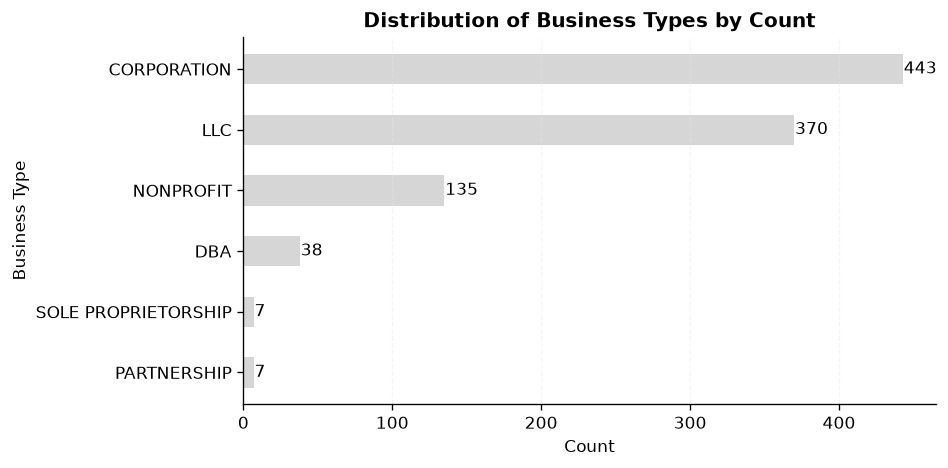

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    y=categories,
    width=values,
    height=0.5,
    color=NEUTRAL_BAR_COLOR
)
ax.set_title("Distribution of Business Types by Count")
ax.set_ylabel("Business Type")
ax.set_xlabel("Count")
ax.grid(axis="x", linestyle="--", alpha=0.4, color=GRID_COLOR)

for bar in ax.patches:
    annotate_bar_count(
        bar=bar,
        ax=ax,
        orient="h"
    )

plt.tight_layout()

fig.savefig(ASSETS_DIR / "business_type_distribution.png")

plt.show()

### 4.3 Top States by Number of Businesses

**Question:** Which states contain the largest number of registered and physical business addresses?

The comparison highlights whether the geographic distribution differs between registered and physical locations.

In [17]:
state_registered_top10 = get_top10(df, "state_registered")
state_physical_top10 = get_top10(df, "state_physical")

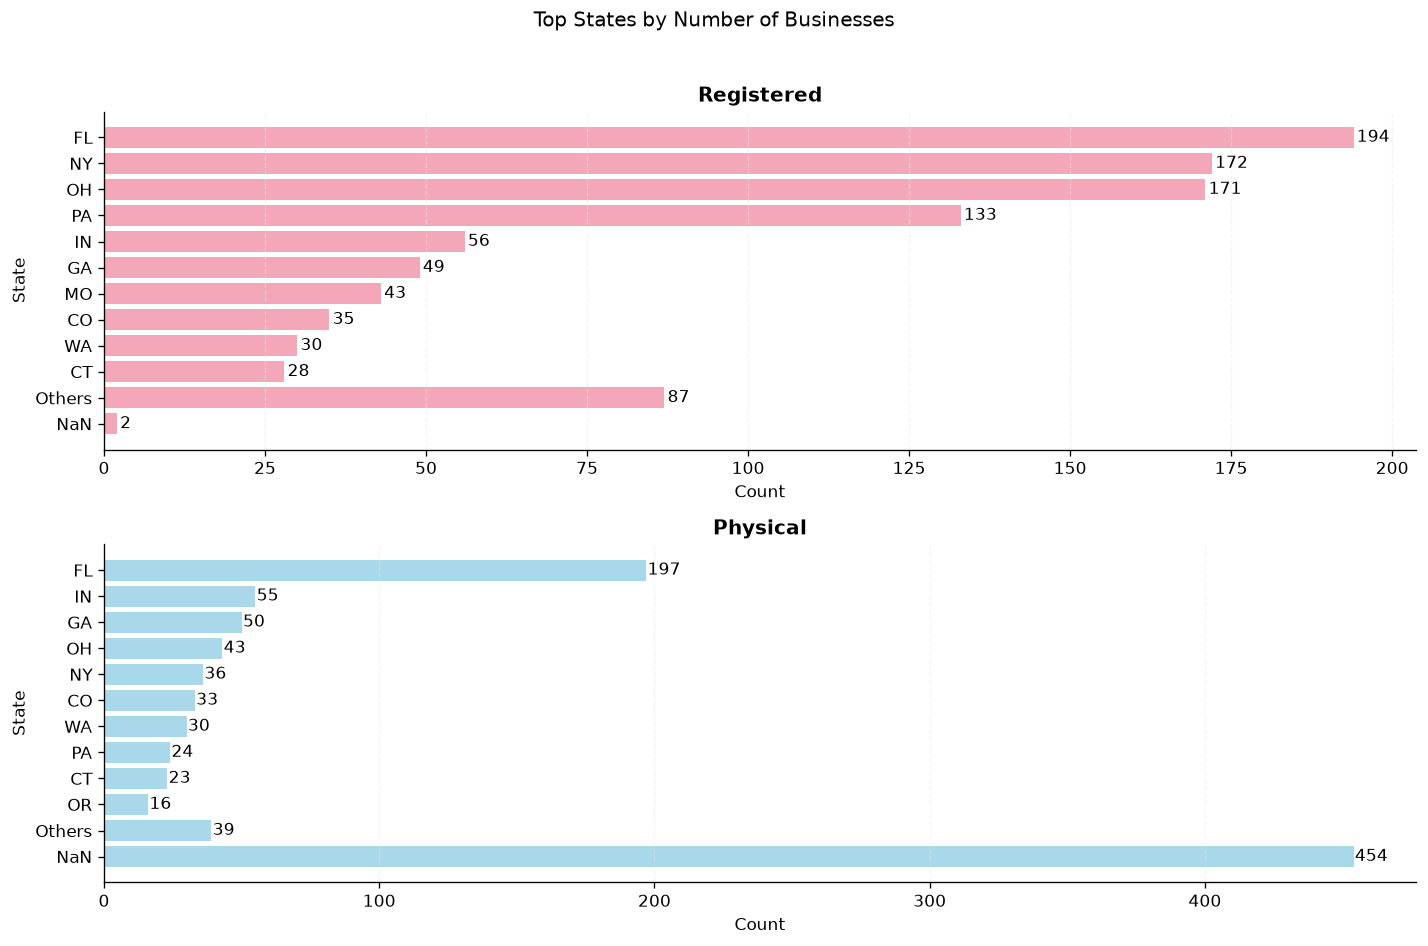

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_horizontal_comparison(ax[0], state_registered_top10, REGISTERED_COLOR, "Registered", "State")

plot_horizontal_comparison(ax[1], state_physical_top10, PHYSICAL_COLOR, "Physical", "State")

fig.suptitle("Top States by Number of Businesses")

plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(ASSETS_DIR / "top_states_registered_vs_physical.png")

plt.show()

### 4.4 Top Cities by Number of Businesses

**Question:** Which cities contain the largest number of registered and physical business addresses?

This complements the state-level analysis by examining business concentration at the city level.

In [19]:
city_registered_top10 = get_top10(df, "city_registered")
city_physical_top10 = get_top10(df, "city_physical")

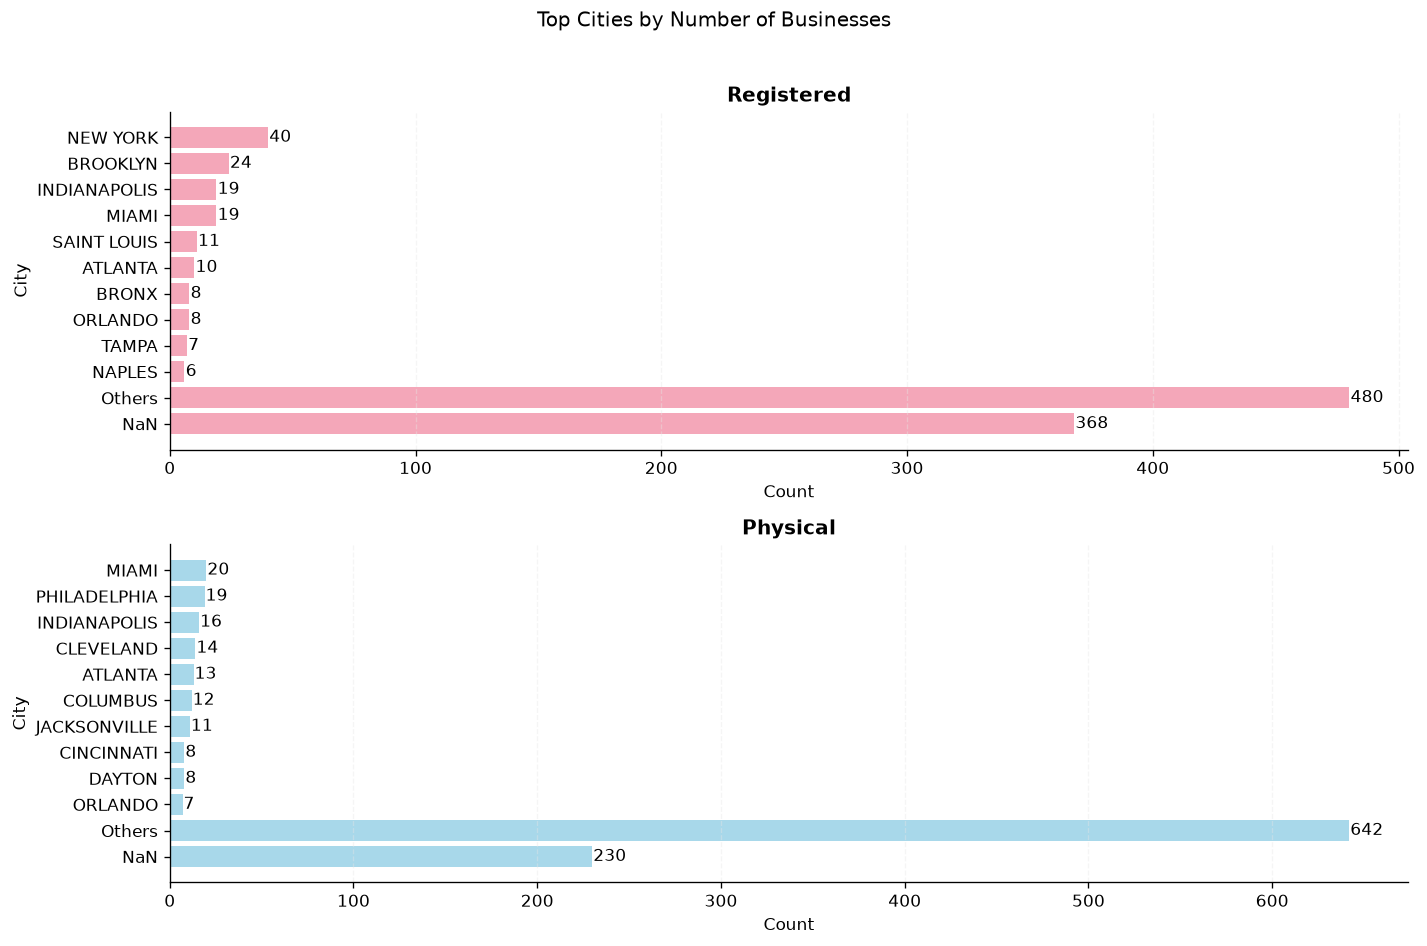

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_horizontal_comparison(ax[0], city_registered_top10, REGISTERED_COLOR, "Registered", "City")

plot_horizontal_comparison(ax[1], city_physical_top10, PHYSICAL_COLOR, "Physical", "City")

fig.suptitle("Top Cities by Number of Businesses")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.5 Business Types by State

**Question:** How does the composition of business types vary across states?

Each bar represents 100% of businesses within a state, making it easier to compare the relative share of each business type.

In [21]:
pivot_registered = df.groupby("state_registered")["business_type"].value_counts().unstack(fill_value=0)
pivot_physical = df.groupby("state_physical")["business_type"].value_counts().unstack(fill_value=0)

In [22]:
pivot_pct_registered = pivot_registered.div(pivot_registered.sum(axis=1), axis=0) * 100
pivot_pct_physical = pivot_physical.div(pivot_physical.sum(axis=1), axis=0) * 100

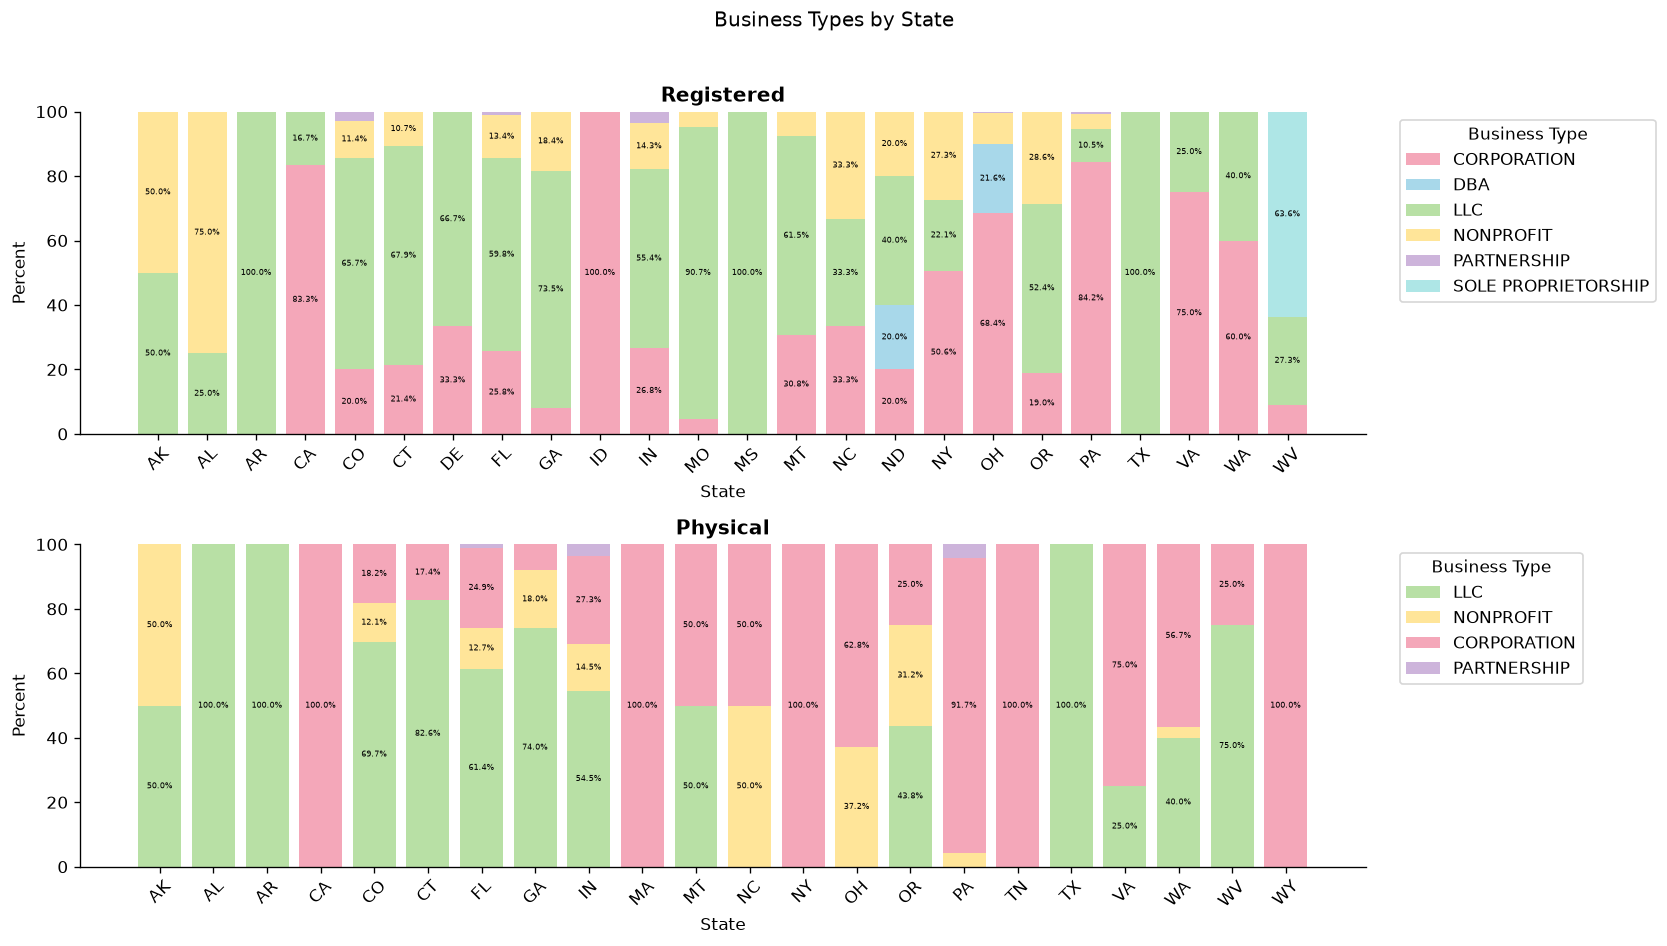

In [23]:
df_registered = pivot_pct_registered.sort_index()
df_physical = pivot_pct_physical.sort_index()

fig, ax = plt.subplots(2, 1, figsize=(14, 8))

plot_stacked_bars(ax[0], df_registered, BUSINESS_TYPE_COLORS, FALLBACK_COLOR)

add_percent_labels(ax[0])

ax[0].set_title("Registered")
ax[0].set_xlabel("State")
ax[0].set_ylabel("Percent")
ax[0].set_ylim(0, 100)
ax[0].tick_params(axis="x", labelrotation=45)
ax[0].legend(title="Business Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plot_stacked_bars(ax[1], df_physical, BUSINESS_TYPE_COLORS, FALLBACK_COLOR)

add_percent_labels(ax[1])

ax[1].set_title("Physical")
ax[1].set_xlabel("State")
ax[1].set_ylabel("Percent")
ax[1].set_ylim(0, 100)
ax[1].tick_params(axis="x", labelrotation=45)
ax[1].legend(title="Business Type", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("Business Types by State")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.6 ZIP Code Validation Results

**Question:** How many ZIP codes passed or failed state-prefix validation?

These charts summarize the results of ZIP code validation for registered and physical addresses.

In [24]:
registered_validation_results = df["registered_zip_state_validation"].value_counts(ascending=True)
physical_validation_results = df["physical_zip_state_validation"].value_counts(ascending=True)

In [25]:
results = registered_validation_results.index.union(physical_validation_results.index)

registered = registered_validation_results.reindex(results, fill_value=0)
physical = physical_validation_results.reindex(results, fill_value=0)

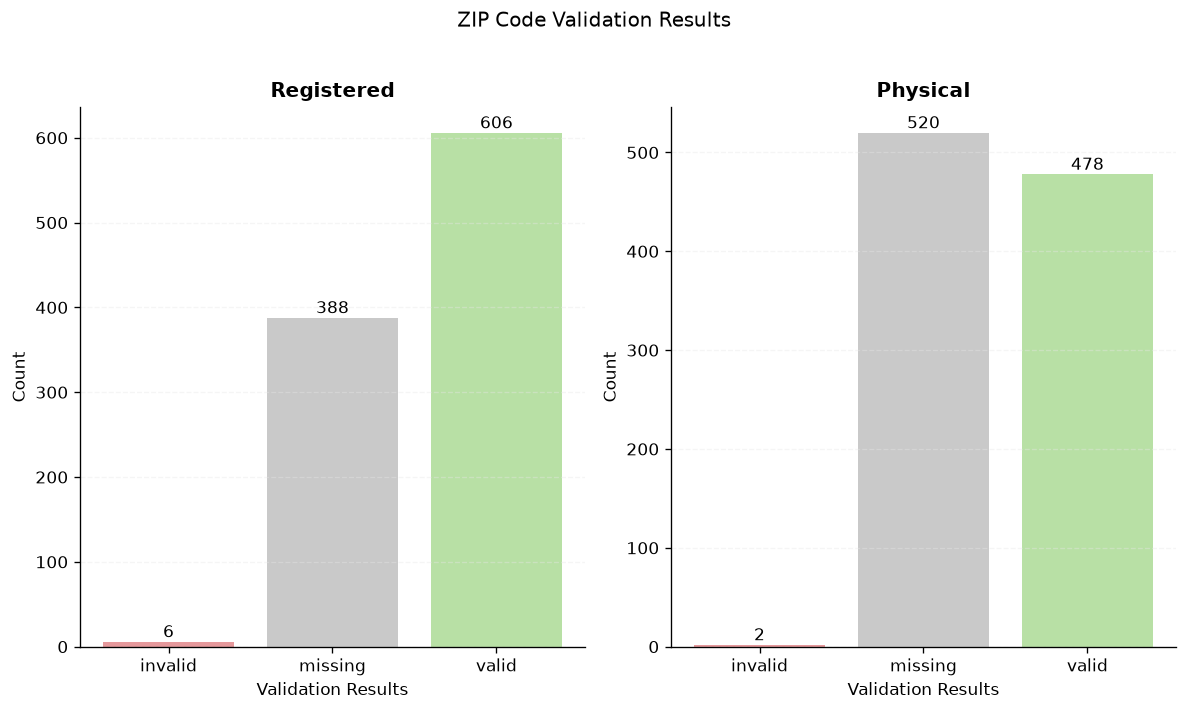

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

colors = [VALIDATION_COLORS[r] for r in results]

ax[0].bar(
    x=results,
    height=registered,
    color=colors
)
ax[0].set_title("Registered")
ax[0].set_xlabel("Validation Results")
ax[0].set_ylabel("Count")
ax[0].grid(axis="y", linestyle="--", alpha=0.4, color=GRID_COLOR)

for bar in ax[0].patches:
    annotate_bar_count(
        bar=bar,
        ax=ax[0],
        orient="v"
    )

ax[1].bar(
    x=results,
    height=physical,
    color=colors
)
ax[1].set_title("Physical")
ax[1].set_xlabel("Validation Results")
ax[1].set_ylabel("Count")
ax[1].grid(axis="y", linestyle="--", alpha=0.4, color=GRID_COLOR)

for bar in ax[1].patches:
    annotate_bar_count(
        bar=bar,
        ax=ax[1],
        orient="v"
    )

fig.suptitle("ZIP Code Validation Results")

plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(ASSETS_DIR / "zip_validation_results.png")

plt.show()

### 4.7 Missing Values Before vs After Cleaning

**Question:** How did missing values change after cleaning?

These changes are reported separately because they represent schema changes rather than reductions in missing values.

- **Removed columns**: `parent`, `sic4`, `duns`, `ein`, `website`, `naics_2017`

- **Added columns**: `registered_zip_state_validation`, `physical_zip_state_validation`

In [27]:
common_columns = sorted(set(df.columns) & set(raw_df.columns))

In [28]:
raw_missing = raw_df.isna().sum().reindex(common_columns, fill_value=0)
processed_missing = df.isna().sum().reindex(common_columns, fill_value=0)

In [29]:
order = (raw_missing + processed_missing).sort_values(ascending=True).index

In [30]:
raw_missing = raw_missing.reindex(order)
processed_missing = processed_missing.reindex(order)

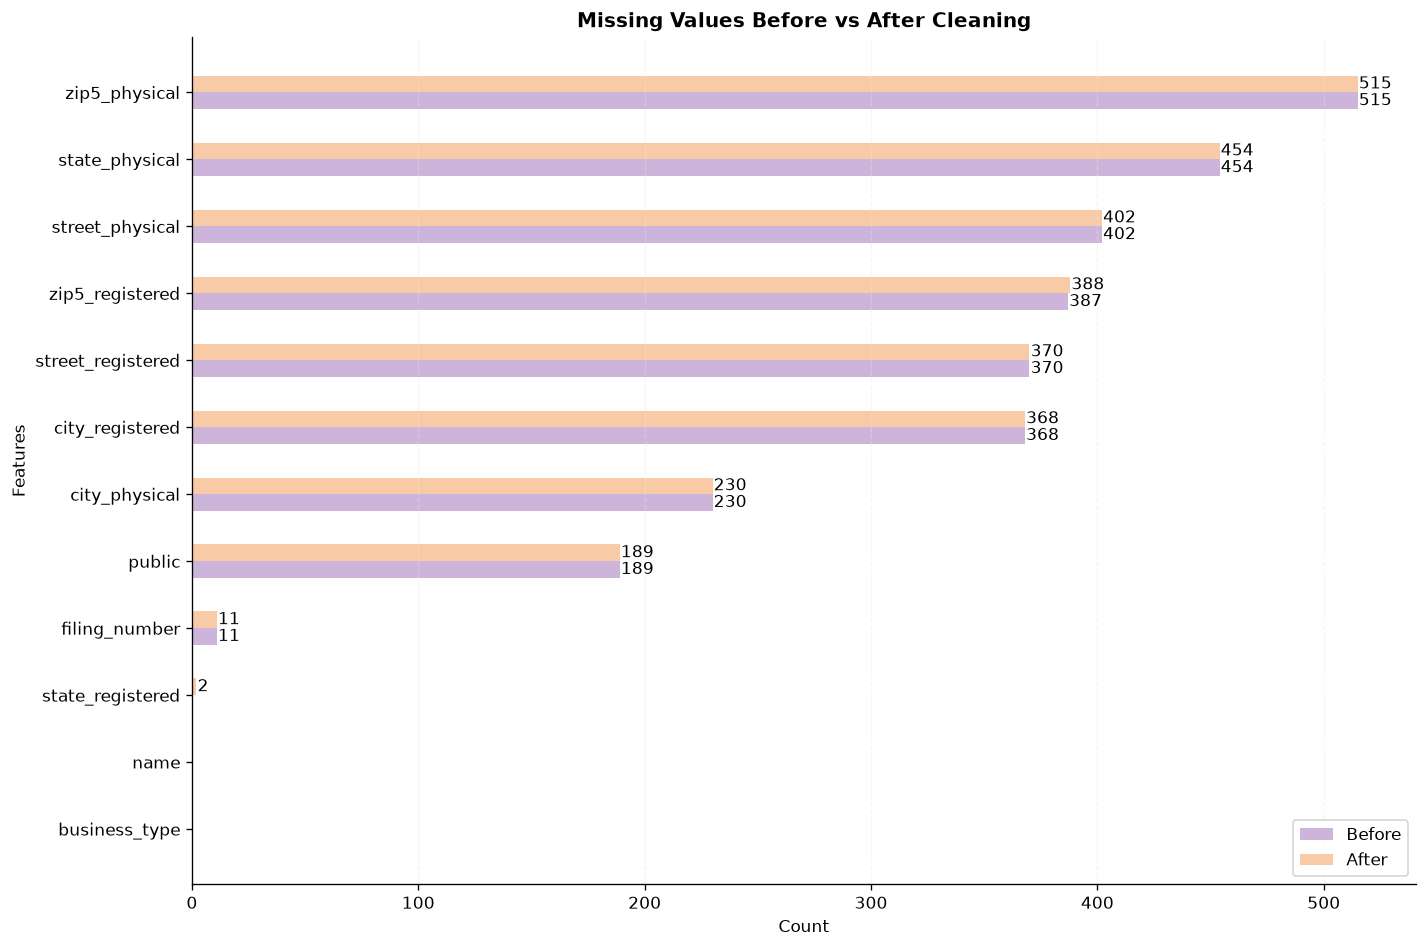

In [31]:
y = np.arange(len(order))
height = 0.5

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    y=y - height/4,
    width=raw_missing.values,
    height=height/2,
    color=BEFORE_COLOR,
    label="Before"
)

for bar in ax.containers[0]:
    annotate_bar_count(
        bar=bar,
        ax=ax,
        orient="h"
    )

ax.barh(
    y=y + height/4,
    width=processed_missing.values,
    height=height/2,
    color=AFTER_COLOR,
    label="After"
)

for bar in ax.containers[1]:
    annotate_bar_count(
        bar=bar,
        ax=ax,
        orient="h"
    )

ax.set_yticks(y)
ax.set_yticklabels(order)
ax.set_title("Missing Values Before vs After Cleaning")
ax.set_xlabel("Count")
ax.set_ylabel("Features")
ax.grid(axis="x", linestyle="--", alpha=0.4, color=GRID_COLOR)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()